# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [2]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [3]:
import librosa
import warnings

In [4]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [6]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [7]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [8]:
def convert_nabatdf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] =  (df['peak_time_ms']-50)/1000
    raven_df['End Time (s)'] = (df['peak_time_ms']-40)/1000
    raven_df['Low Freq (Hz)'] = df['peak_freq_hz']-2000
    raven_df['High Freq (Hz)'] = df['peak_freq_hz']+2000
    raven_df['prediction'] = df['prediction']
    raven_df['score'] = df['score']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_nabatdf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = (df['peak_time_ms']-50)/1000
    bd2_df['end_time'] = (df['peak_time_ms']-40)/1000
    bd2_df['low_freq'] = df['peak_freq_hz']-2000
    bd2_df['high_freq'] = df['peak_freq_hz']+2000
    bd2_df['prediction'] = df['prediction']
    bd2_df['score'] = df['score']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_kaleidoscopedf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] = df['OFFSET']
    raven_df['End Time (s)'] = df['OFFSET'] + df['DURATION']
    raven_df['Low Freq (Hz)'] = df['Fmin']
    raven_df['High Freq (Hz)'] = df['Fmax']
    raven_df['input_file'] = df['IN FILE']
    raven_df['input_dir'] = df['INDIR']
    raven_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        raven_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        raven_df['TOP1MATCH'] = df['TOP1MATCH']
    raven_df['TOP1DIST'] = df['TOP1DIST']
    raven_df['TOP2MATCH'] = df['TOP2MATCH']
    raven_df['TOP2DIST'] = df['TOP2DIST']
    raven_df['TOP3MATCH'] = df['TOP3MATCH']
    raven_df['TOP3DIST'] = df['TOP3DIST']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_kaleidoscopedf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = df['OFFSET']
    bd2_df['end_time'] = df['OFFSET'] + df['DURATION']
    bd2_df['low_freq'] = df['Fmin']
    bd2_df['high_freq'] = df['Fmax']
    bd2_df['input_file'] = df['IN FILE']
    bd2_df['input_dir'] = df['INDIR']
    bd2_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        bd2_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        bd2_df['TOP1MATCH'] = df['TOP1MATCH']
    bd2_df['TOP1DIST'] = df['TOP1DIST']
    bd2_df['TOP2MATCH'] = df['TOP2MATCH']
    bd2_df['TOP2DIST'] = df['TOP2DIST']
    bd2_df['TOP3MATCH'] = df['TOP3MATCH']
    bd2_df['TOP3DIST'] = df['TOP3DIST']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_raventxtdf_to_bd2df(raventxt_df):
    bd2_human_df = raventxt_df[1::2].copy()
    bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB',
                                'Delta Time (s)':'delta_time_s'}, inplace=True)
    bd2_human_df.sort_values('start_time', inplace=True)
    
    return bd2_human_df

def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [9]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
#  '20210910_030000':'Foliage'}
extension = ".txt"
sep = "\t"
raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
bd2_dets_save_dir = Path(f'20250115__group_threshold_sweep_results')

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [10]:
wav_filename = '20220826_070000'
site = file_sites[wav_filename]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

In [11]:
snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep)
bd2_human_df = snr_included_ravenpro_human_txt.copy()
bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df.sort_values('start_time', inplace=True)
bd2_human_df

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF,2.567162
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF,6.879404
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF,7.902035
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF,1.782390
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF,1.514990
...,...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF,9.656562
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF,6.562988
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF,8.990165
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF,5.589297


In [21]:
def plot_audio_seg(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()


def plot_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    Pxx, freqs, t, im = plt.specgram(audio_seg, NFFT=nfft, Fs=fs, cmap=cmap, vmin=vmin, vmax=vmax)

    ax = plt.gca()
    if len(plot_dets)>0:
        plot_dets = plot_dets[(plot_dets['start_time']>=start)&(plot_dets['end_time']<=(start+duration))]
        for i, row in plot_dets.iterrows():
            rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                            (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                            linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
            ax.add_patch(rect)
            ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

    plt.yticks(ticks=np.linspace(0, 256e3/2, 6).astype('int'), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration, 6), 
               labels=np.linspace(start, start+duration, 6, dtype=plot_xtype).round(2), rotation=0)
    plt.xlabel("Time (s)")
    plt.twinx(ax=ax)
    plt.yticks(ticks=np.linspace(0, 256e3/2, 6).astype('int'), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.ylim(0, 256e3/2)

    plt.show()
    return Pxx

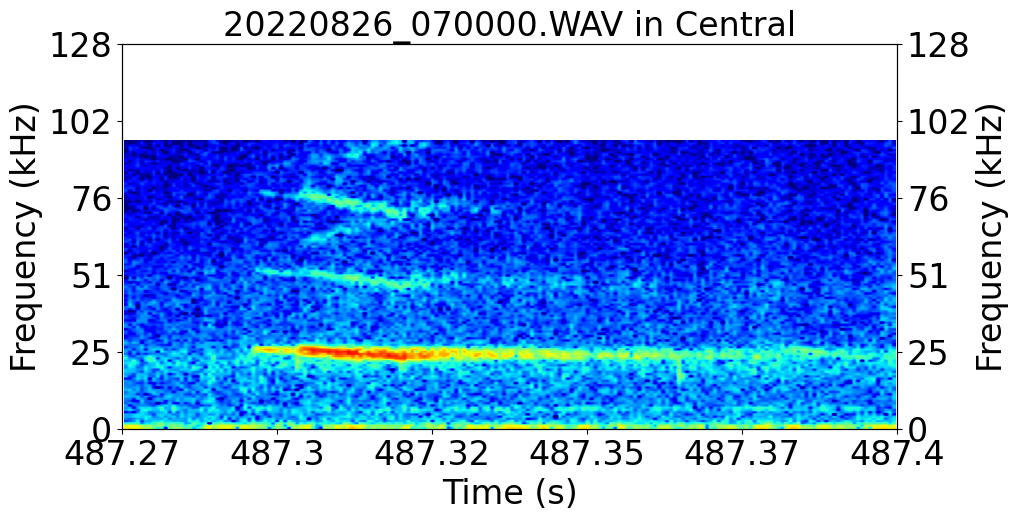

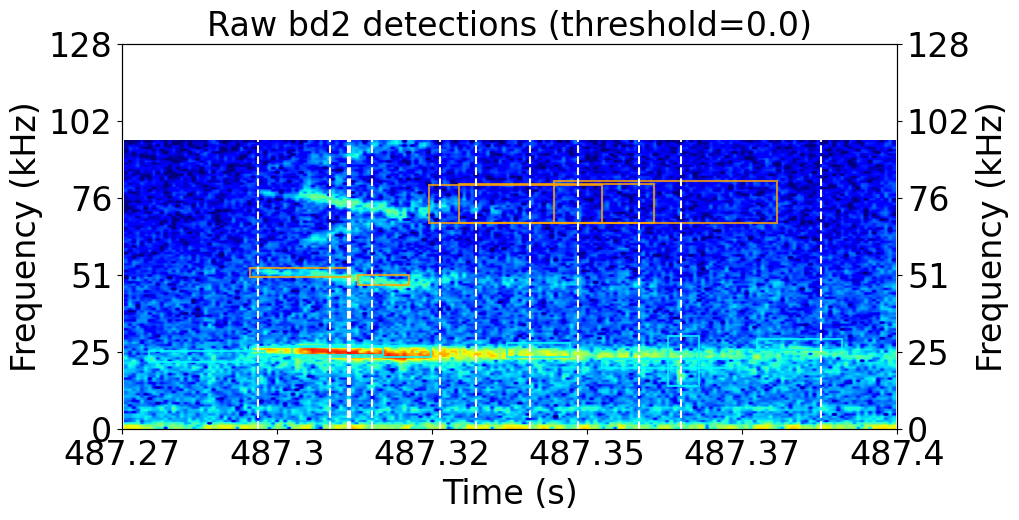

In [67]:
# Below we filter our detections dataframe to only get the detections corresponding to the above audio file
audio_file = sf.SoundFile(plot_file)
fs = audio_file.samplerate
start = 487.27
duration = 0.13
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmin = -120
vmax = -40
audio_features = dict()
audio_features['file_path'] = Path(plot_file)
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration

spec_features = dict()
spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax


spec_features['plot_title'] = f"{audio_features['file_path'].name} in {site}"
Pxx = plot_dets_over_audio(audio_features, spec_features, pd.DataFrame())

plot_thresh = 0.00
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00

ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")

filepath = bd2_dets_save_dir / save_loc
batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
batdetect2_df_selected = batdetect2_df[batdetect2_df['det_prob']>=plot_thresh].copy()
spec_features['plot_title'] = f"Raw bd2 detections (threshold={plot_thresh})"
Pxx = plot_dets_over_audio(audio_features, spec_features, batdetect2_df_selected)

In [68]:
OVERLAP_TIME_THRESHOLD = 0.008

In [69]:
example_bd2df = batdetect2_df_selected[(batdetect2_df_selected['start_time']>=start)&(batdetect2_df_selected['end_time']<=(start+duration))]
example_bd2df = example_bd2df.sort_values('peak_frequency_time_SPECTROGRAM').reset_index(drop=True)
example_bd2df

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,LF,487.292833,26250.0,25920.0,12.332810,487.2745,487.2940,22031,25689,Nyctalus leisleri,0.014,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1,LF,487.304867,25500.0,25920.0,21.207803,487.2985,487.3218,23750,27434,Nyctalus leisleri,0.150,0.221,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
2,HF,487.307867,50250.0,49920.0,12.398475,487.2915,487.3083,50390,53589,Pipistrellus pygmaeus,0.047,0.064,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3,LF,487.308200,25500.0,25920.0,36.125806,487.2915,487.3138,24609,27315,Nyctalus leisleri,0.283,0.381,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
4,HF,487.311900,48750.0,49920.0,4.621735,487.3095,487.3181,47812,51169,Pipistrellus pipistrellus,0.017,0.030,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
5,HF,487.323333,74250.0,72960.0,-8.541423,487.3215,487.3505,68437,80929,Rhinolophus ferrumequinum,0.022,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
6,HF,487.329300,72750.0,72960.0,-11.503866,487.3265,487.3592,68437,81394,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
7,LF,487.338400,24750.0,24000.0,-8.885457,487.3345,487.3451,23750,28622,Nyctalus leisleri,0.012,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
8,HF,487.346433,69750.0,72960.0,-12.728558,487.3425,487.3799,68437,82330,Rhinolophus ferrumequinum,0.024,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
9,LF,487.356733,24000.0,24000.0,-7.967229,487.3505,487.3716,20312,23149,Nyctalus leisleri,0.017,0.033,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [70]:
dist_matrix = np.zeros((len(example_bd2df), len(example_bd2df)))
for i in range(len(example_bd2df)):
    row = example_bd2df.iloc[i]
    dist_matrix[:,i] = ((example_bd2df['peak_frequency_time_SPECTROGRAM'] - row['peak_frequency_time_SPECTROGRAM']).values)

In [71]:
pd.DataFrame(dist_matrix)

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.000000,-0.012033,-0.015033,-0.015367,-0.019067,-0.030500,-0.036467,-0.045567,-0.053600,-0.063900,-0.070867,-0.094367
1,0.012033,0.000000,-0.003000,-0.003333,-0.007033,-0.018467,-0.024433,-0.033533,-0.041567,-0.051867,-0.058833,-0.082333
2,0.015033,0.003000,0.000000,-0.000333,-0.004033,-0.015467,-0.021433,-0.030533,-0.038567,-0.048867,-0.055833,-0.079333
3,0.015367,0.003333,0.000333,0.000000,-0.003700,-0.015133,-0.021100,-0.030200,-0.038233,-0.048533,-0.055500,-0.079000
4,0.019067,0.007033,0.004033,0.003700,0.000000,-0.011433,-0.017400,-0.026500,-0.034533,-0.044833,-0.051800,-0.075300
5,0.030500,0.018467,0.015467,0.015133,0.011433,0.000000,-0.005967,-0.015067,-0.023100,-0.033400,-0.040367,-0.063867
6,0.036467,0.024433,0.021433,0.021100,0.017400,0.005967,0.000000,-0.009100,-0.017133,-0.027433,-0.034400,-0.057900
7,0.045567,0.033533,0.030533,0.030200,0.026500,0.015067,0.009100,0.000000,-0.008033,-0.018333,-0.025300,-0.048800
8,0.053600,0.041567,0.038567,0.038233,0.034533,0.023100,0.017133,0.008033,0.000000,-0.010300,-0.017267,-0.040767
9,0.063900,0.051867,0.048867,0.048533,0.044833,0.033400,0.027433,0.018333,0.010300,0.000000,-0.006967,-0.030467


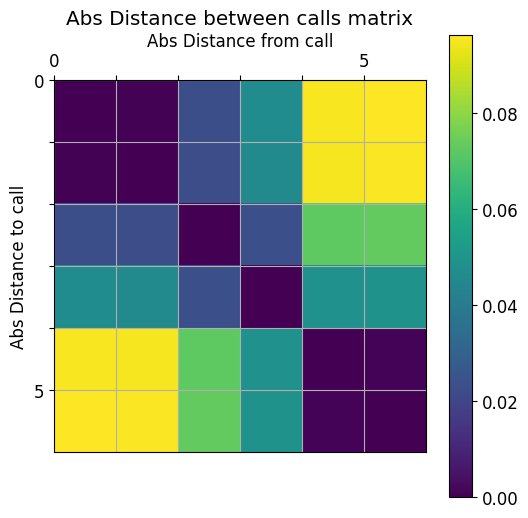

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
plt.rcParams.update({'font.size':12})

ax.set_title('Abs Distance between calls matrix')
im = ax.imshow((np.abs(dist_matrix)))
ax.set_xlabel('Abs Distance from call')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Abs Distance to call')
ticks = np.arange(0, len(example_bd2df))
plt_ticks = ['']*len(example_bd2df)
plt_ticks[::5] = ticks[::5]

ax.set_xticks(ticks=ticks-0.5, labels=plt_ticks)
ax.set_yticks(ticks=ticks-0.5, labels=plt_ticks)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.grid(which='both')
fig.colorbar(im, orientation='vertical')

plt.show()

In [51]:
association_mat = np.ones((len(example_bd2df), len(example_bd2df)), dtype='bool')

In [53]:
considered_inds = np.where(np.abs(dist_matrix[:,0])<OVERLAP_TIME_THRESHOLD)[0]
considered_dets = example_bd2df.iloc[considered_inds]
considered_dets

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,LF,487.292833,26250.0,25920.0,12.33281,487.2745,487.294,22031,25689,Nyctalus leisleri,0.014,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [48]:
considered_inds

array([3, 4])

In [50]:
det_choices = np.zeros(len(considered_inds))
det_choices

array([0., 0.])

In [52]:
likely_call_ind = considered_dets['det_prob'].argmax()
likely_call_det = considered_dets.iloc[likely_call_ind]
likely_call_det

freq_group                                                                        LF
peak_frequency_time_SPECTROGRAM                                           487.304867
peak_frequency_SPECTROGRAM                                                   25500.0
peak_frequency_WELCH                                                         25920.0
SNR                                                                        21.207803
start_time                                                                  487.2985
end_time                                                                    487.3218
low_freq                                                                       23750
high_freq                                                                      27434
class                                                              Nyctalus leisleri
class_prob                                                                      0.15
det_prob                                                         

In [53]:
det_choices[likely_call_ind] = 1
det_choices

array([0., 1.])

In [54]:
association_mat[considered_inds, 0] = det_choices
association_mat

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  T

In [55]:
dist_mat_comp_batdetect2_df = batdetect2_df_selected.copy()
association_mat = np.ones((len(dist_mat_comp_batdetect2_df), len(dist_mat_comp_batdetect2_df)), dtype='bool')
for index in range(len(dist_mat_comp_batdetect2_df)):
    row = dist_mat_comp_batdetect2_df.iloc[index]
    dist_to_all_calls = ((dist_mat_comp_batdetect2_df['peak_frequency_time_SPECTROGRAM'] - row['peak_frequency_time_SPECTROGRAM']).values)

    considered_inds = np.where(np.abs(dist_to_all_calls)<OVERLAP_TIME_THRESHOLD)[0]
    considered_dets = batdetect2_df_selected.iloc[considered_inds]

    det_choices = np.zeros(len(considered_inds))
    likely_call_ind = considered_dets['det_prob'].argmax()

    det_choices[likely_call_ind] = 1
    association_mat[considered_inds, index] = det_choices

In [56]:
association_mat

array([[False, False, False, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ..., False, False,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

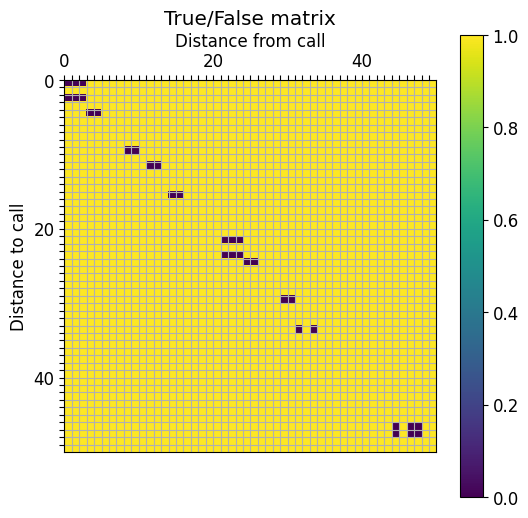

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

plt_size = 50
ax.set_title('True/False matrix')
im = ax.imshow(association_mat[:plt_size,:plt_size])
ax.set_xlabel('Distance from call')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Distance to call')

ticks = np.arange(0, plt_size)
plt_ticks = ['']*plt_size
plt_ticks[::20] = ticks[::20]

ax.set_xticks(ticks=ticks-0.5, labels=plt_ticks)
ax.set_yticks(ticks=ticks-0.5, labels=plt_ticks)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.grid(which='both')
fig.colorbar(im, orientation='vertical')

plt.show()

In [58]:
reduced_overlaps_batdetect2_df = batdetect2_df_selected[np.logical_and.reduce(association_mat, axis=1)]

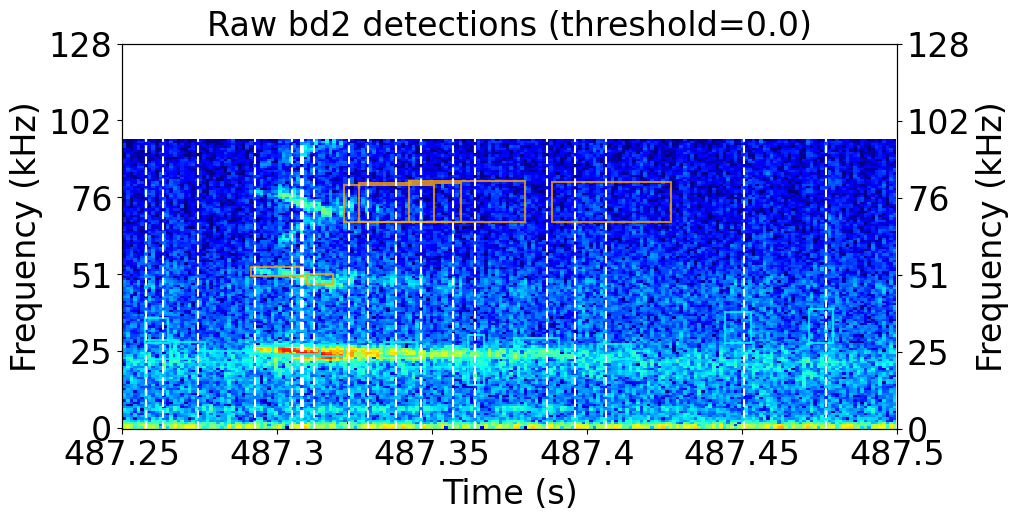

In [59]:
audio_seg = audio_features['audio_seg']
fs = audio_features['sample_rate']
start = audio_features['start']
duration = audio_features['duration']
plot_dets = batdetect2_df_selected

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

plt.figure(figsize=(10, 5))
plt.rcParams.update({'font.size': 24})
plt.title(spec_features['plot_title'], fontsize=24)
mpl_specgram_window = plt.mlab.window_hanning(np.ones(nfft))
f, t, Sxx = scipy.signal.spectrogram(audio_seg, fs, detrend=False,
                               nfft=nfft, 
                               window=mpl_specgram_window
                              )
max_value_across_bins = Sxx[np.where(Sxx==np.max(Sxx))]
peak_freq = f[np.where(Sxx==np.max(Sxx))[0]]
peak_freq_time = t[np.where(Sxx==np.max(Sxx))[1]]
plt.pcolormesh(t, f, 10*np.log10(Sxx), cmap=cmap, vmin=vmin, vmax=vmax)
plt.axvline(x=peak_freq_time, linestyle='dashed', color='white')

ax = plt.gca()
if len(plot_dets)>0:
    plot_dets = plot_dets[(plot_dets['start_time']>=start)&(plot_dets['end_time']<=(start+duration))]
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
        ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')
        ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 256e3/2, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plot_xtype = 'float'
if (duration > 60):
    plot_xtype = 'int'
plt.xticks(ticks=np.linspace(0, duration, 6), 
            labels=np.linspace(start, start+duration, 6, dtype=plot_xtype), rotation=0)
plt.xlabel("Time (s)")
plt.twinx(ax=ax)
plt.yticks(ticks=np.linspace(0, 256e3/2, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.ylim(0, 256e3/2)

plt.show()

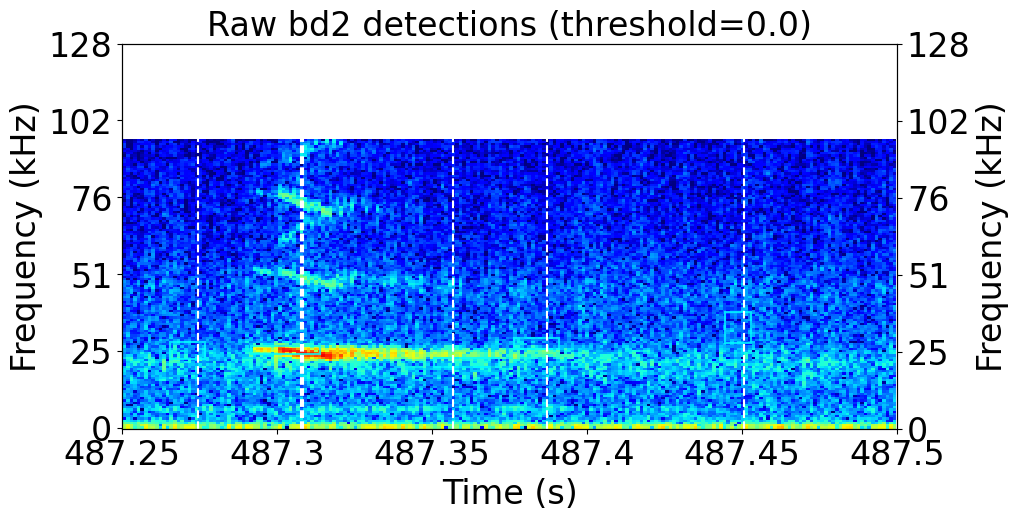

In [60]:
audio_seg = audio_features['audio_seg']
fs = audio_features['sample_rate']
start = audio_features['start']
duration = audio_features['duration']
plot_dets = reduced_overlaps_batdetect2_df

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

plt.figure(figsize=(10, 5))
plt.rcParams.update({'font.size': 24})
plt.title(spec_features['plot_title'], fontsize=24)
mpl_specgram_window = plt.mlab.window_hanning(np.ones(nfft))
f, t, Sxx = scipy.signal.spectrogram(audio_seg, fs, detrend=False,
                               nfft=nfft, 
                               window=mpl_specgram_window
                              )
max_value_across_bins = Sxx[np.where(Sxx==np.max(Sxx))]
peak_freq = f[np.where(Sxx==np.max(Sxx))[0]]
peak_freq_time = t[np.where(Sxx==np.max(Sxx))[1]]
plt.pcolormesh(t, f, 10*np.log10(Sxx), cmap=cmap, vmin=vmin, vmax=vmax)
plt.axvline(x=peak_freq_time, linestyle='dashed', color='white')

ax = plt.gca()
if len(plot_dets)>0:
    plot_dets = plot_dets[(plot_dets['start_time']>=start)&(plot_dets['end_time']<=(start+duration))]
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
        ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')
        ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 256e3/2, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plot_xtype = 'float'
if (duration > 60):
    plot_xtype = 'int'
plt.xticks(ticks=np.linspace(0, duration, 6), 
            labels=np.linspace(start, start+duration, 6, dtype=plot_xtype), rotation=0)
plt.xlabel("Time (s)")
plt.twinx(ax=ax)
plt.yticks(ticks=np.linspace(0, 256e3/2, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.ylim(0, 256e3/2)

plt.show()

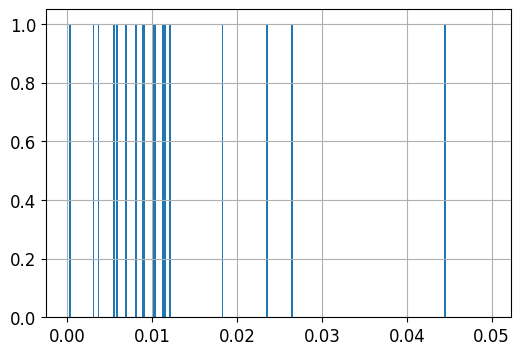

In [61]:
next_calls_pftSPEC = example_bd2df['peak_frequency_time_SPECTROGRAM'][1:].reset_index(drop=True)
cur_calls_pftSPEC = example_bd2df['peak_frequency_time_SPECTROGRAM'][:-1].reset_index(drop=True)
pftSPEC_intervals = next_calls_pftSPEC - cur_calls_pftSPEC

plt.figure(figsize=(6,4))
plt.rcParams.update({'font.size':12})
pftSPEC_intervals.hist(bins=np.arange(0,0.05,2e-4))
plt.show()

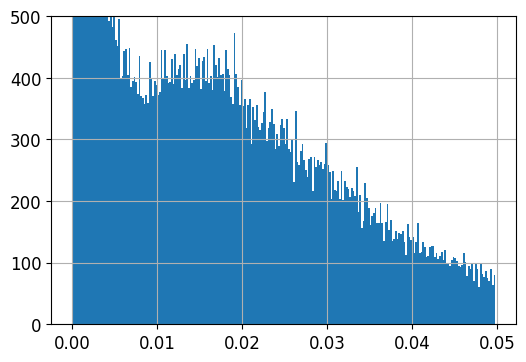

In [62]:
next_calls_pftSPEC = batdetect2_df_selected.sort_values('peak_frequency_time_SPECTROGRAM')['peak_frequency_time_SPECTROGRAM'][1:].reset_index(drop=True)
cur_calls_pftSPEC = batdetect2_df_selected.sort_values('peak_frequency_time_SPECTROGRAM')['peak_frequency_time_SPECTROGRAM'][:-1].reset_index(drop=True)
pftSPEC_intervals = next_calls_pftSPEC - cur_calls_pftSPEC
plt.figure(figsize=(6,4))
plt.rcParams.update({'font.size':12})
pftSPEC_intervals.hist(bins=np.arange(0,0.05,2e-4))
plt.ylim(0, 500)
plt.show()

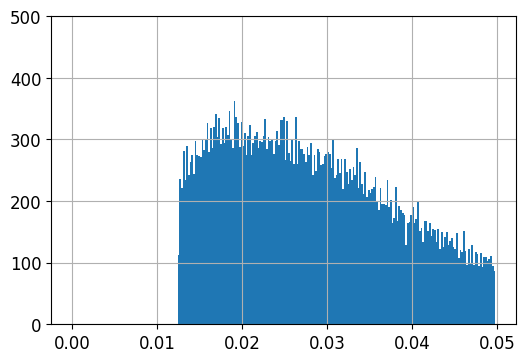

In [63]:
next_calls_pftSPEC = reduced_overlaps_batdetect2_df.sort_values('peak_frequency_time_SPECTROGRAM')['peak_frequency_time_SPECTROGRAM'][1:].reset_index(drop=True)
cur_calls_pftSPEC = reduced_overlaps_batdetect2_df.sort_values('peak_frequency_time_SPECTROGRAM')['peak_frequency_time_SPECTROGRAM'][:-1].reset_index(drop=True)
pftSPEC_intervals = next_calls_pftSPEC - cur_calls_pftSPEC
plt.figure(figsize=(6,4))
plt.rcParams.update({'font.size':12})
pftSPEC_intervals.hist(bins=np.arange(0,0.05,2e-4))
plt.ylim(0, 500)
plt.show()

In [64]:
FREQUENCY_COLOR_MAPPINGS = {'LF':'cyan', 'HF':'orange'}

In [65]:
save_loc

PosixPath('bd2__threshold0p00_chunksize2_20220826_070000.csv')

In [66]:
ravenpro_df = convert_bd2df_ravenpro(reduced_overlaps_batdetect2_df)
ravenpro_df.to_csv(f'{bd2_dets_save_dir}/{save_loc.stem}_REDUCED_OVERLAPS.txt', sep=sep, index=False)